<a href="https://colab.research.google.com/github/KeithRajbhandari/KRB-HTML/blob/main/Week_5_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initializing Supply Chain Intent Classification Pipeline...

Hardware Acceleration: CPU
Loading Zero-Shot Classifier ('facebook/bart-large-mnli')...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Model loaded successfully.

Classifying 10 supplier messages...


Processing Batches:   0%|          | 0/3 [00:00<?, ?it/s]


Classification complete in 58.98 seconds.
Data successfully exported to local environment as: 'soleo_supply_chain_intents.csv'

--- Classified Messages Preview ---


,raw_message,cleaned_message,predicted_intent,confidence_score
0,[Ticket#1001] The container with the synthetic...,The container with the synthetic nylon rolls f...,Logistics & Shipping Delays,0.5673
1,TKT-4922: During inspection of the activewear ...,"During inspection of the activewear leggings, ...",Quality Control & Defects,0.5792
2,"Can you provide an updated quotation for 5,000...","Can you provide an updated quotation for 5,000...",Pricing & Quotation,0.5960
3,[Ticket#502] If we confirm the order for the n...,If we confirm the order for the new leggings c...,Supplier Lead Time,0.2829
4,We are running low on the matte black syntheti...,We are running low on the matte black syntheti...,Inventory & Restock Inquiry,0.4896



--- Intent Distribution Summary ---
predicted_intent
Pricing & Quotation            3
Logistics & Shipping Delays    2
Quality Control & Defects      2
Inventory & Restock Inquiry    2
Supplier Lead Time             1

--- Escalation Queue ---
Found 3 messages below 0.4 confidence requiring human review.


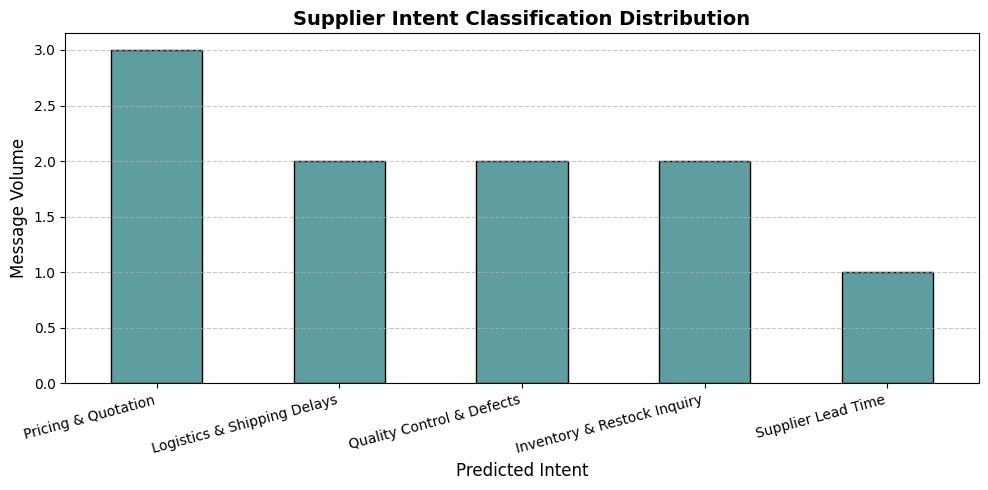

In [4]:
# 1. Install dependencies
!pip install -q "transformers>=4.40.0" torch pandas accelerate matplotlib tqdm

import re
import time
import warnings
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display
from transformers import pipeline

# Suppress verbose terminal warnings for a cleaner output
warnings.filterwarnings('ignore')

def main():
    print("Initializing Supply Chain Intent Classification Pipeline...\n")

    # --- 1. Environment & Model Setup ---
    # Automatically detect and utilize GPU if available in Colab
    device = 0 if torch.cuda.is_available() else -1
    print(f"Hardware Acceleration: {'GPU (CUDA)' if device == 0 else 'CPU'}")

    model_name = "facebook/bart-large-mnli"
    print(f"Loading Zero-Shot Classifier ('{model_name}')...")

    try:
        classifier = pipeline("zero-shot-classification", model=model_name, device=device)
    except Exception as e:
        print(f"Error loading model: {e}")
        return

    print("Model loaded successfully.\n")

    # --- 2. Define Candidate Intents ---
    candidate_labels = [
        "Logistics & Shipping Delays",
        "Quality Control & Defects",
        "Inventory & Restock Inquiry",
        "Pricing & Quotation",
        "Supplier Lead Time"
    ]

    # --- 3. Domain-Specific Mock Dataset ---
    sample_supplier_messages = [
        "[Ticket#1001] The container with the synthetic nylon rolls from Guangzhou has been delayed at customs. Expect a 4-day hold before release.",
        "TKT-4922: During inspection of the activewear leggings, we noticed the stitching tension on batch #A4 is too tight and causing bunching.",
        "Can you provide an updated quotation for 5,000 units of the women's sports bras? We need to lock in the unit price before the Canton Fair.",
        "[Ticket#502] If we confirm the order for the new leggings collection today, what is the estimated manufacturing lead time?",
        "We are running low on the matte black synthetic nylon fabric. Can you check your warehouse to see if we can restock an additional 200 yards by Friday?",
        "TKT-993: The dye fastness test on the latest synthetic blends failed. The colors are bleeding in warm water washes. We need to pause production.",
        "Shipping quote attached for the air freight of 10 boxes of activewear samples from China to Nepal. Please approve so we can dispatch.",
        "[Ticket#8821] We are facing raw material cost increases for nylon. The price per yard will increase by 4% starting Q4. Sincerely, Supplier Ops",
        "Are the requested sizing labels (XS, S, M, L) in stock at the factory, or do we need to order a new batch from the trim supplier?",
        "TKT-119: The factory floor is currently at full capacity. Any new orders for synthetic activewear will have a minimum 60-day lead time."
    ]

    # --- 4. Text Preprocessing Function ---
    def clean_message(text: str) -> str:
        """Strips ticket IDs, trailing colons/spaces, and email signatures prior to classification."""
        # Fixed: Catch trailing colons or spaces after ticket numbers to prevent leading artifacts
        text = re.sub(r"(\[?Ticket#\d+\]?|TKT-\d+)\s*:?", "", text, flags=re.IGNORECASE)
        text = re.sub(r"(Best regards|Thanks|Sincerely),.*", "", text, flags=re.IGNORECASE | re.DOTALL)
        return re.sub(r"\s+", " ", text).strip()

    # --- 5. Batched Inference Execution ---
    print(f"Classifying {len(sample_supplier_messages)} supplier messages...")
    start_time = time.time()

    cleaned_texts = [clean_message(msg) for msg in sample_supplier_messages]
    results = []
    batch_size = 4

    # tqdm provides a visual progress bar during inference
    for i in tqdm(range(0, len(cleaned_texts), batch_size), desc="Processing Batches"):
        batch = cleaned_texts[i:i + batch_size]
        batch_out = classifier(batch, candidate_labels, multi_label=False)

        # Handle dictionary output when batch size resolves to 1
        if isinstance(batch_out, dict):
            batch_out = [batch_out]

        for out in batch_out:
            results.append({
                "predicted_intent": out['labels'][0],
                "confidence_score": round(out['scores'][0], 4)
            })

    elapsed_time = time.time() - start_time
    print(f"\nClassification complete in {elapsed_time:.2f} seconds.")

    # --- 6. Data Structuring & Output Export ---
    results_df = pd.DataFrame({
        "raw_message": sample_supplier_messages,
        "cleaned_message": cleaned_texts,
        "predicted_intent": [r['predicted_intent'] for r in results],
        "confidence_score": [r['confidence_score'] for r in results],
    })

    # Assignment Requirement: Export to CSV
    csv_filename = "soleo_supply_chain_intents.csv"
    results_df.to_csv(csv_filename, index=False)
    print(f"Data successfully exported to local environment as: '{csv_filename}'\n")

    print("--- Classified Messages Preview ---")
    display(results_df.head(5))

    # --- 7. Assignment Enhancements: Analytics & Visuals ---
    print("\n--- Intent Distribution Summary ---")
    intent_counts = results_df['predicted_intent'].value_counts()
    print(intent_counts.to_string())

    # Fixed: Lowered Confidence Threshold for manual human review to better suit zero-shot multi-class probability spread
    THRESHOLD = 0.40
    low_confidence_df = results_df[results_df['confidence_score'] < THRESHOLD]
    print(f"\n--- Escalation Queue ---")
    print(f"Found {len(low_confidence_df)} messages below {THRESHOLD} confidence requiring human review.")

    # Matplotlib Dashboard
    plt.figure(figsize=(10, 5))
    intent_counts.plot(kind='bar', color='cadetblue', edgecolor='black')
    plt.title('Supplier Intent Classification Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Intent', fontsize=12)
    plt.ylabel('Message Volume', fontsize=12)
    plt.xticks(rotation=15, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Execute the pipeline
if __name__ == "__main__":
    main()